In [1]:
from pydataxm.pydataxm import ReadDB
import pandas as pd

obj = ReadDB()
variables = obj.all_variables()

# Filtrar las relacionadas con embalses
embalses = variables[variables['MetricId'].str.contains(
    'mbal|olum|Hidro|Apor', case=False, na=False
)]

print(embalses[['MetricId', 'MetricName', 'Entity']].to_string())

               MetricId                                   MetricName   Entity
120            AporEner                 Aportes  Energía por Sistema  Sistema
131    AporEnerMediHist  Aportes Media Histórica Energía por Sistema  Sistema
141            AporEner                     Aportes  Energía por Rio      Rio
142    AporEnerMediHist      Aportes Media Histórica Energía por Rio      Rio
152          AporCaudal                       Aportes Caudal por Rio      Rio
153  AporCaudalMediHist       Aportes Media Histórica Caudal por Rio      Rio
164            PorcApor                        Aportes % por Sistema  Sistema
165            PorcApor                            Aportes % por Rio      Rio
190     ListadoEmbalses              Listado de embalses por Sistema  Sistema


In [9]:
from datetime import datetime

print("Descargando aportes % del sistema 2010-2026...")
df_apor = obj.request_data(
    "PorcApor",
    "Sistema",
    datetime(2010, 1, 1),
    datetime(2026, 6, 1)
)

print("Shape:", df_apor.shape)
print("Columnas:", df_apor.columns.tolist())
print(df_apor.head(10))

Descargando aportes % del sistema 2010-2026...
Shape: (6027, 3)
Columnas: ['Id', 'Value', 'Date']
        Id    Value       Date
0  Sistema  0.60716 2010-01-01
1  Sistema  0.57363 2010-01-02
2  Sistema  0.57767 2010-01-03
3  Sistema  0.53787 2010-01-04
4  Sistema  0.54826 2010-01-05
5  Sistema  0.55548 2010-01-06
6  Sistema  0.52884 2010-01-07
7  Sistema  0.49352 2010-01-08
8  Sistema  0.62417 2010-01-09
9  Sistema  0.59772 2010-01-10


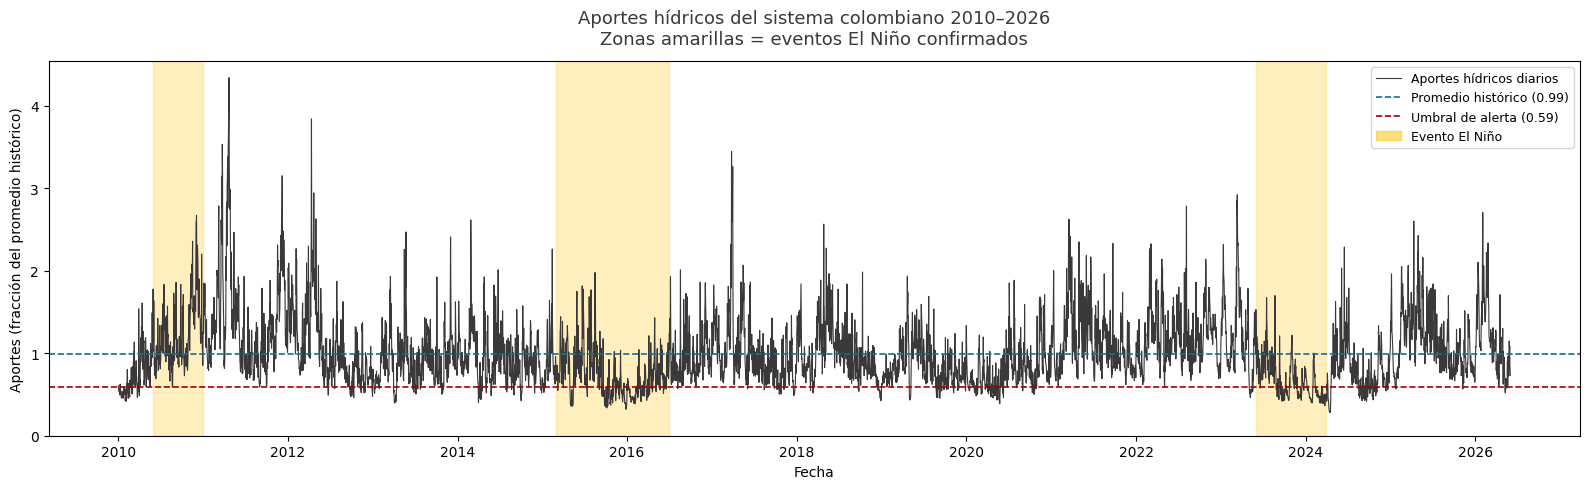

Gráfica guardada en outputs/aportes_enos.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Preparar datos
df_apor['Date'] = pd.to_datetime(df_apor['Date'])
df_apor = df_apor.sort_values('Date').reset_index(drop=True)

# Períodos El Niño confirmados en Colombia
nino = [
    ("2010-06-01", "2010-12-31"),
    ("2015-03-01", "2016-06-30"),
    ("2023-06-01", "2024-03-31"),
]

fig, ax = plt.subplots(figsize=(16, 5))

# Línea principal
ax.plot(df_apor['Date'], df_apor['Value'], 
        color='#3A3838', linewidth=0.8, label='Aportes hídricos diarios')

# Promedio histórico
promedio = df_apor['Value'].mean()
ax.axhline(promedio, color='#1F6B8E', linewidth=1.2, 
           linestyle='--', label=f'Promedio histórico ({promedio:.2f})')

# Umbral de alerta
umbral = promedio * 0.6
ax.axhline(umbral, color='#A00000', linewidth=1.2, 
           linestyle='--', label=f'Umbral de alerta ({umbral:.2f})')

# Sombrear períodos ENOS
for inicio, fin in nino:
    ax.axvspan(pd.Timestamp(inicio), pd.Timestamp(fin),
               alpha=0.25, color='#FFC000')

# Leyenda manual para ENOS
nino_patch = mpatches.Patch(color='#FFC000', alpha=0.5, label='Evento El Niño')
ax.legend(handles=[*ax.get_legend_handles_labels()[0], nino_patch], 
          fontsize=9)

ax.set_title('Aportes hídricos del sistema colombiano 2010–2026\n'
             'Zonas amarillas = eventos El Niño confirmados', 
             fontsize=13, color='#3A3838', pad=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Aportes (fracción del promedio histórico)')
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig('../outputs/aportes_enos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada en outputs/aportes_enos.png")

Días en El Niño:  1007
Días normales:    5020

Promedio El Niño:  0.820
Promedio normal:   1.021

Mediana El Niño:   0.734
Mediana normal:    0.927


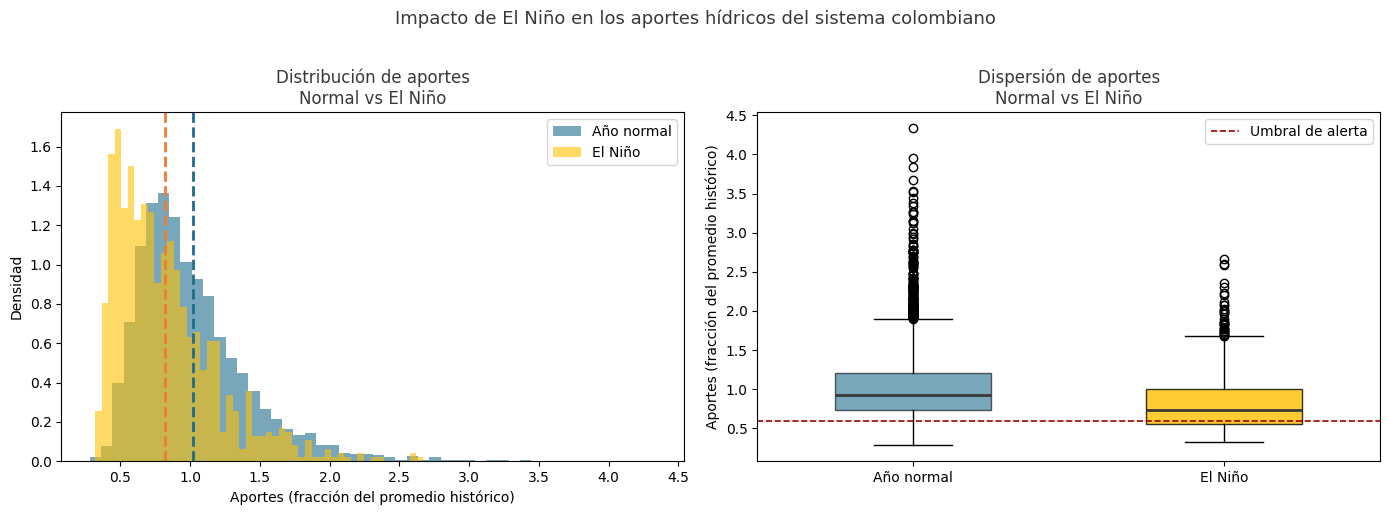

Gráfica guardada.


In [12]:
import numpy as np

# Clasificar días según fase ENOS
nino_periodos = [
    ("2010-06-01", "2010-12-31"),
    ("2015-03-01", "2016-06-30"),
    ("2023-06-01", "2024-03-31"),
]

def es_nino(fecha):
    for inicio, fin in nino_periodos:
        if pd.Timestamp(inicio) <= fecha <= pd.Timestamp(fin):
            return True
    return False

df_apor['es_nino'] = df_apor['Date'].apply(es_nino)

dias_nino   = df_apor[df_apor['es_nino'] == True]['Value']
dias_normal = df_apor[df_apor['es_nino'] == False]['Value']

print(f"Días en El Niño:  {len(dias_nino)}")
print(f"Días normales:    {len(dias_normal)}")
print(f"\nPromedio El Niño:  {dias_nino.mean():.3f}")
print(f"Promedio normal:   {dias_normal.mean():.3f}")
print(f"\nMediana El Niño:   {dias_nino.median():.3f}")
print(f"Mediana normal:    {dias_normal.median():.3f}")

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma comparativo
axes[0].hist(dias_normal, bins=50, alpha=0.6, 
             color='#1F6B8E', label='Año normal', density=True)
axes[0].hist(dias_nino, bins=50, alpha=0.6, 
             color='#FFC000', label='El Niño', density=True)
axes[0].axvline(dias_normal.mean(), color='#1F6B8E', 
                linewidth=2, linestyle='--')
axes[0].axvline(dias_nino.mean(), color='#ED7D31', 
                linewidth=2, linestyle='--')
axes[0].set_title('Distribución de aportes\nNormal vs El Niño', 
                  fontsize=12, color='#3A3838')
axes[0].set_xlabel('Aportes (fracción del promedio histórico)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Boxplot comparativo
data_box = [dias_normal.values, dias_nino.values]
bp = axes[1].boxplot(data_box, labels=['Año normal', 'El Niño'],
                     patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#1F6B8E')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#FFC000')
bp['boxes'][1].set_alpha(0.8)
for median in bp['medians']:
    median.set_color('#3A3838')
    median.set_linewidth(2)

axes[1].axhline(0.59, color='#A00000', linewidth=1.2,
                linestyle='--', label='Umbral de alerta')
axes[1].set_title('Dispersión de aportes\nNormal vs El Niño',
                  fontsize=12, color='#3A3838')
axes[1].set_ylabel('Aportes (fracción del promedio histórico)')
axes[1].legend()

plt.suptitle('Impacto de El Niño en los aportes hídricos del sistema colombiano',
             fontsize=13, color='#3A3838', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/distribucion_nino_vs_normal.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

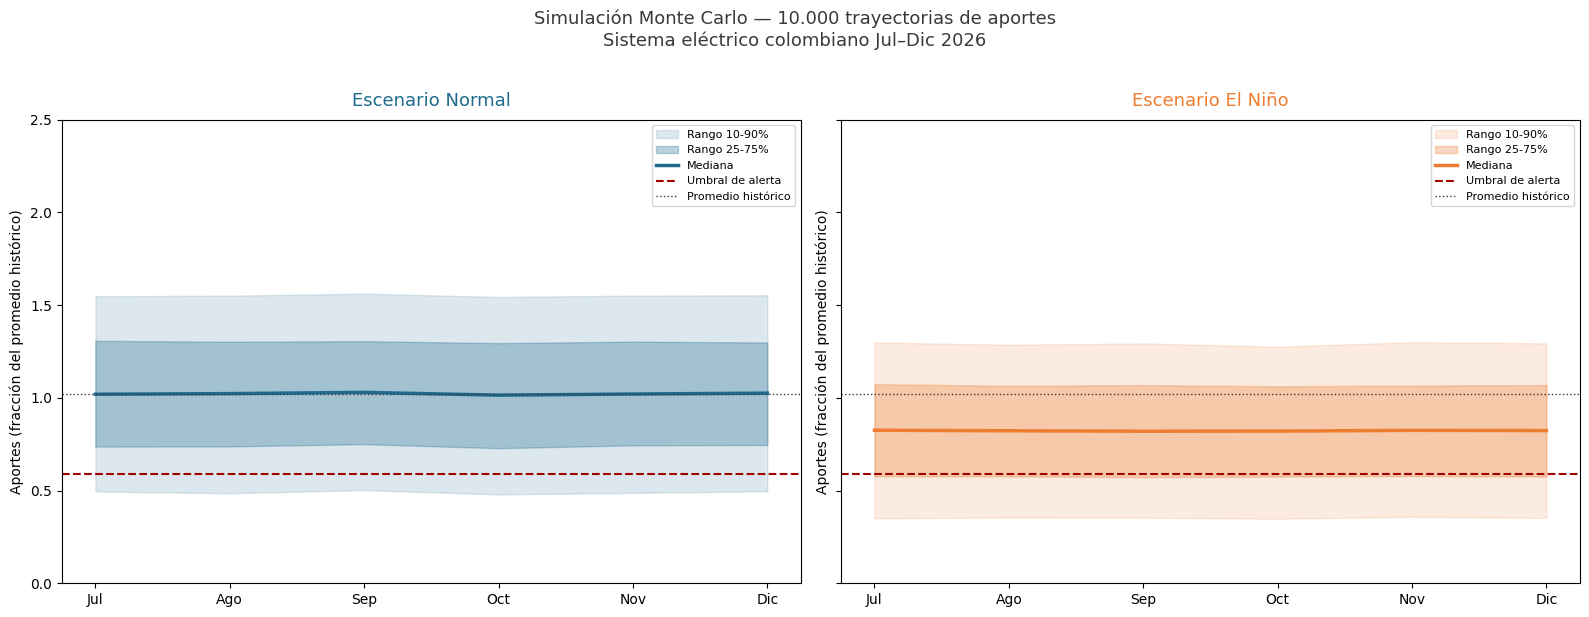

Gráfica guardada.


In [26]:
np.random.seed(42)
N_simulaciones = 10000
N_meses = 6
meses = ['Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Parámetros históricos por fase
media_normal = dias_normal.mean()
std_normal   = dias_normal.std()

media_nino   = dias_nino.mean()
std_nino     = dias_nino.std()

# Simular trayectorias
sim_normal = np.random.normal(media_normal, std_normal, 
                               (N_simulaciones, N_meses))
sim_nino   = np.random.normal(media_nino, std_nino, 
                               (N_simulaciones, N_meses))

# Clip para que no haya valores negativos
sim_normal = np.clip(sim_normal, 0, None)
sim_nino   = np.clip(sim_nino,   0, None)

# Gráfica abanico
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, sim, titulo, color in zip(
    axes,
    [sim_normal, sim_nino],
    ['Escenario Normal', 'Escenario El Niño'],
    ['#1F6B8E', '#ED7D31']
):
    # Percentiles
    p10 = np.percentile(sim, 10, axis=0)
    p25 = np.percentile(sim, 25, axis=0)
    p50 = np.percentile(sim, 50, axis=0)
    p75 = np.percentile(sim, 75, axis=0)
    p90 = np.percentile(sim, 90, axis=0)

    x = range(N_meses)

    ax.fill_between(x, p10, p90, alpha=0.15, color=color, label='Rango 10-90%')
    ax.fill_between(x, p25, p75, alpha=0.30, color=color, label='Rango 25-75%')
    ax.plot(x, p50, color=color, linewidth=2.5, label='Mediana')
    ax.axhline(0.59, color='#A00000', linewidth=1.5,
               linestyle='--', label='Umbral de alerta')
    ax.axhline(media_normal, color='#3A3838', linewidth=1,
               linestyle=':', label='Promedio histórico')

    ax.set_xticks(range(N_meses))
    ax.set_xticklabels(meses)
    ax.set_title(titulo, fontsize=13, color=color, pad=10)
    ax.set_ylabel('Aportes (fracción del promedio histórico)')
    ax.set_ylim(0, 2.5)
    ax.legend(fontsize=8)

plt.suptitle('Simulación Monte Carlo — 10.000 trayectorias de aportes\n'
             'Sistema eléctrico colombiano Jul–Dic 2026',
             fontsize=13, color='#3A3838', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/montecarlo_trayectorias.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

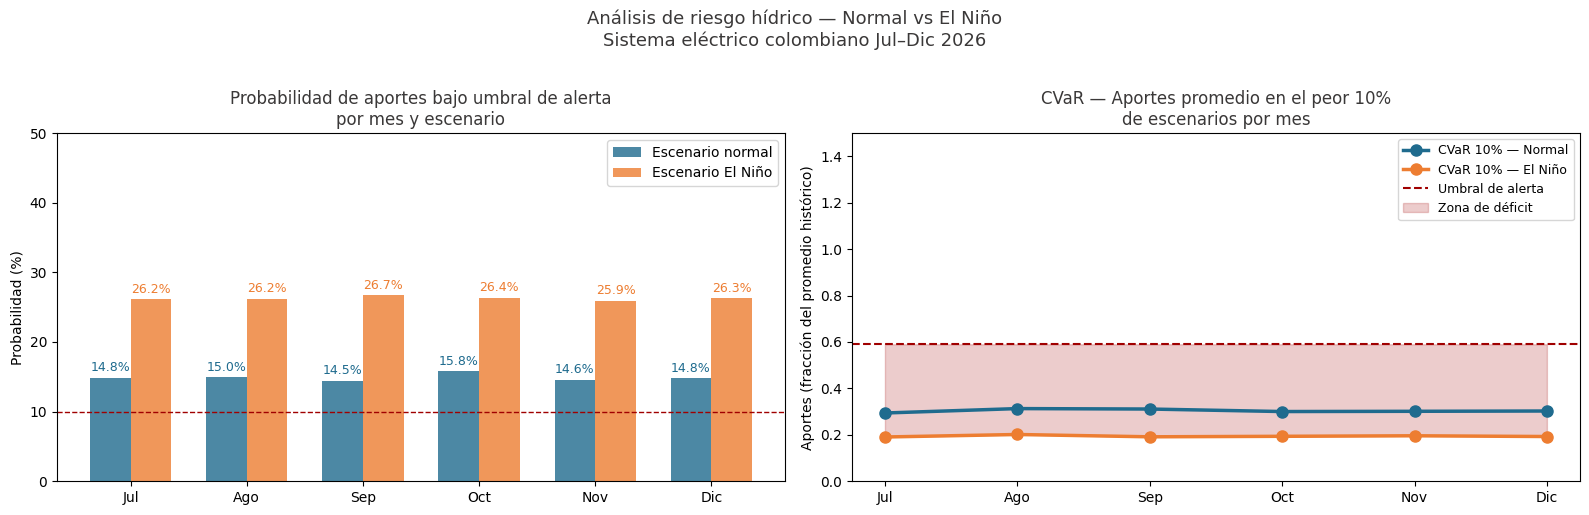


Resumen de riesgo:
Probabilidad promedio de crisis en año normal: 14.9%
Probabilidad promedio de crisis en El Niño:    26.3%


In [21]:
# Calcular probabilidad de caer bajo el umbral en cada escenario
umbral_alerta = 0.59

prob_critico_normal = (sim_normal < umbral_alerta).mean(axis=0) * 100
prob_critico_nino   = (sim_nino   < umbral_alerta).mean(axis=0) * 100

# CVaR simple — promedio del peor 10% de escenarios
cvar_normal = np.mean(np.sort(sim_normal, axis=0)[:int(N_simulaciones*0.10), :], axis=0)
cvar_nino   = np.mean(np.sort(sim_nino,   axis=0)[:int(N_simulaciones*0.10), :], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfica 1 — Probabilidad de crisis por mes
x = np.arange(N_meses)
width = 0.35

bars1 = axes[0].bar(x - width/2, prob_critico_normal, width,
                     color='#1F6B8E', alpha=0.8, label='Escenario normal')
bars2 = axes[0].bar(x + width/2, prob_critico_nino, width,
                     color='#ED7D31', alpha=0.8, label='Escenario El Niño')

# Etiquetas encima de cada barra
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color='#1F6B8E')
for bar in bars2:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color='#ED7D31')

axes[0].set_xticks(x)
axes[0].set_xticklabels(meses)
axes[0].set_title('Probabilidad de aportes bajo umbral de alerta\npor mes y escenario',
                   fontsize=12, color='#3A3838')
axes[0].set_ylabel('Probabilidad (%)')
axes[0].set_ylim(0, 50)
axes[0].legend()
axes[0].axhline(10, color='#A00000', linewidth=1,
                linestyle='--', label='Umbral de riesgo aceptable (10%)')

# Gráfica 2 — CVaR por mes
axes[1].plot(meses, cvar_normal, 'o-', color='#1F6B8E',
             linewidth=2.5, markersize=8, label='CVaR 10% — Normal')
axes[1].plot(meses, cvar_nino, 'o-', color='#ED7D31',
             linewidth=2.5, markersize=8, label='CVaR 10% — El Niño')
axes[1].axhline(umbral_alerta, color='#A00000', linewidth=1.5,
                linestyle='--', label='Umbral de alerta')
axes[1].fill_between(range(N_meses), cvar_nino, umbral_alerta,
                     where=(cvar_nino < umbral_alerta),
                     alpha=0.2, color='#A00000', label='Zona de déficit')

axes[1].set_title('CVaR — Aportes promedio en el peor 10%\nde escenarios por mes',
                   fontsize=12, color='#3A3838')
axes[1].set_ylabel('Aportes (fracción del promedio histórico)')
axes[1].set_ylim(0, 1.5)
axes[1].legend(fontsize=9)

plt.suptitle('Análisis de riesgo hídrico — Normal vs El Niño\n'
             'Sistema eléctrico colombiano Jul–Dic 2026',
             fontsize=13, color='#3A3838', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/riesgo_cvar.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResumen de riesgo:")
print(f"Probabilidad promedio de crisis en año normal: {prob_critico_normal.mean():.1f}%")
print(f"Probabilidad promedio de crisis en El Niño:    {prob_critico_nino.mean():.1f}%")

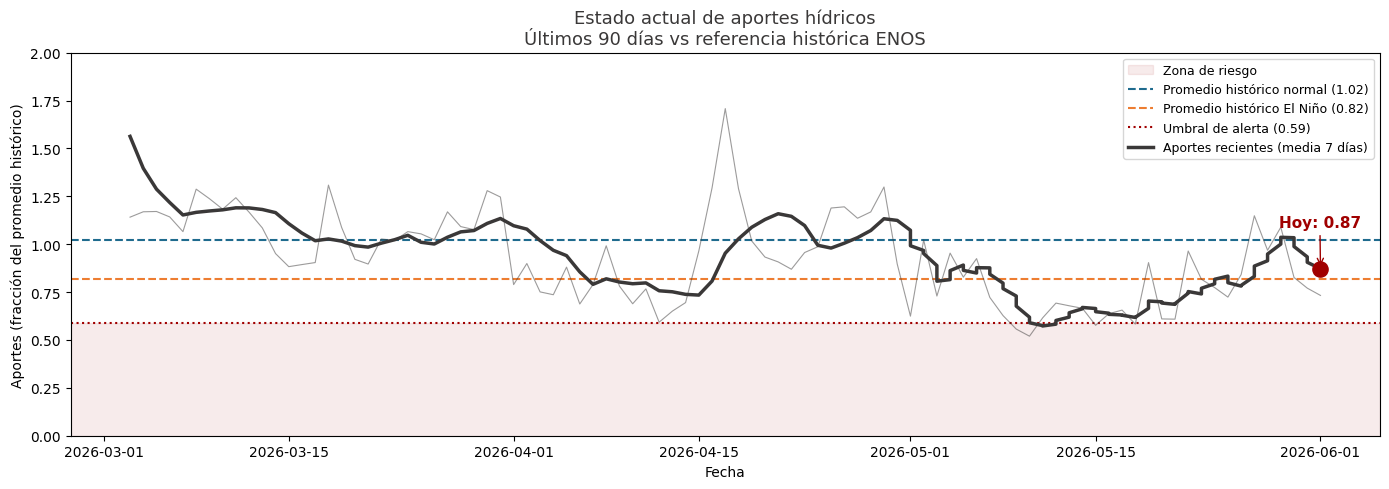


Fecha más reciente en datos: 2026-06-01
Aporte actual (media 7d):    0.872
Promedio histórico normal:   1.021
Promedio histórico El Niño:  0.820
Umbral de alerta:            0.590

📊  MODERADO: Aportes por debajo del promedio normal


In [25]:
# Situación actual — últimos 90 días vs histórico ENOS
hoy = df_apor['Date'].max()
hace_90 = hoy - pd.Timedelta(days=90)

df_reciente = df_apor[df_apor['Date'] >= hace_90].copy()

# Promedio móvil 7 días para suavizar
df_apor['ma7'] = df_apor['Value'].rolling(7).mean()
df_reciente = df_apor[df_apor['Date'] >= hace_90].copy()

fig, ax = plt.subplots(figsize=(14, 5))

# Zona de riesgo
ax.axhspan(0, 0.59, alpha=0.08, color='#A00000', label='Zona de riesgo')

# Promedio histórico normal
ax.axhline(media_normal, color='#1F6B8E', linewidth=1.5,
           linestyle='--', label=f'Promedio histórico normal ({media_normal:.2f})')

# Promedio histórico El Niño
ax.axhline(media_nino, color='#ED7D31', linewidth=1.5,
           linestyle='--', label=f'Promedio histórico El Niño ({media_nino:.2f})')

# Umbral de alerta
ax.axhline(0.59, color='#A00000', linewidth=1.5,
           linestyle=':', label='Umbral de alerta (0.59)')

# Datos recientes
ax.plot(df_reciente['Date'], df_reciente['Value'],
        color='#3A3838', linewidth=0.8, alpha=0.5)
ax.plot(df_reciente['Date'], df_reciente['ma7'],
        color='#3A3838', linewidth=2.5, label='Aportes recientes (media 7 días)')

# Punto más reciente
ultimo_valor = df_reciente['ma7'].dropna().iloc[-1]
ultima_fecha = df_reciente['Date'].iloc[-1]
ax.scatter(ultima_fecha, ultimo_valor, 
           color='#A00000', s=120, zorder=5)
ax.annotate(f'Hoy: {ultimo_valor:.2f}',
            xy=(ultima_fecha, ultimo_valor),
            xytext=(-30, 30), textcoords='offset points',
            fontsize=11, color='#A00000', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#A00000'))

ax.set_title(f'Estado actual de aportes hídricos\n'
             f'Últimos 90 días vs referencia histórica ENOS',
             fontsize=13, color='#3A3838')
ax.set_xlabel('Fecha')
ax.set_ylabel('Aportes (fracción del promedio histórico)')
ax.set_ylim(0, 2.0)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/estado_actual_aportes.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Diagnóstico automático
print(f"\nFecha más reciente en datos: {ultima_fecha.date()}")
print(f"Aporte actual (media 7d):    {ultimo_valor:.3f}")
print(f"Promedio histórico normal:   {media_normal:.3f}")
print(f"Promedio histórico El Niño:  {media_nino:.3f}")
print(f"Umbral de alerta:            0.590")
print()
if ultimo_valor < 0.59:
    print("⚠️  ALERTA: Aportes actuales en zona crítica")
elif ultimo_valor < media_nino:
    print("⚠️  PRECAUCIÓN: Aportes por debajo del promedio El Niño")
elif ultimo_valor < media_normal:
    print("📊  MODERADO: Aportes por debajo del promedio normal")
else:
    print("✅  NORMAL: Aportes dentro del rango histórico normal")

In [27]:
from datetime import datetime

print("Descargando generación hidráulica...")
df_hidro = obj.request_data(
    "Gene",
    "Sistema",
    datetime(2010, 1, 1),
    datetime(2026, 6, 1)
)

print("Shape:", df_hidro.shape)
print("Columnas:", df_hidro.columns.tolist())
print(df_hidro.head())

Descargando generación hidráulica...
Shape: (6026, 27)
Columnas: ['Id', 'Values_code', 'Values_Hour01', 'Values_Hour02', 'Values_Hour03', 'Values_Hour04', 'Values_Hour05', 'Values_Hour06', 'Values_Hour07', 'Values_Hour08', 'Values_Hour09', 'Values_Hour10', 'Values_Hour11', 'Values_Hour12', 'Values_Hour13', 'Values_Hour14', 'Values_Hour15', 'Values_Hour16', 'Values_Hour17', 'Values_Hour18', 'Values_Hour19', 'Values_Hour20', 'Values_Hour21', 'Values_Hour22', 'Values_Hour23', 'Values_Hour24', 'Date']
        Id Values_code  Values_Hour01  Values_Hour02  Values_Hour03  \
0  Sistema     Sistema     5609982.23     5296750.71     4919467.58   
1  Sistema     Sistema     4443442.83     4238022.31     4153685.87   
2  Sistema     Sistema     4771417.74     4520041.29     4364500.03   
3  Sistema     Sistema     4705250.02     4493314.06     4399068.67   
4  Sistema     Sistema     5171964.92     4939629.25     4840107.60   

   Values_Hour04  Values_Hour05  Values_Hour06  Values_Hour07  Values_

In [29]:
# Buscar métricas de generación
gen_vars = variables[variables['MetricName'].str.contains(
    'hidra|termo|hidro|térm|tterm|Gene', case=False, na=False
)]
print(gen_vars[['MetricId', 'MetricName', 'Entity']].to_string())

                  MetricId                                           MetricName   Entity
4                     Gene                               Generación por Sistema  Sistema
5                 GeneIdea                         Generación Ideal por Sistema  Sistema
10                    Gene                               Generación por Recurso  Recurso
21                GeneIdea                         Generación Ideal por Recurso  Recurso
35           GeneSeguridad                  Generación de Seguridad por Recurso  Recurso
36         GeneFueraMerito               Generación Fuera de Mérito por Recurso  Recurso
38            GeneProgDesp                    Generación Programada por Recurso  Recurso
39          GeneProgRedesp         Generación Programada Redespacho por Recurso  Recurso
112    DesvGenVariableDesp              Desviación generación variable despacho  Recurso
114  DesvGenVariableRedesp            Desviación generación variable redespacho  Recurso
192            Listad

In [31]:
print("Descargando generación por recurso 2023-2026...")

df_gene_recurso = obj.request_data(
    "Gene",
    "Recurso",
    datetime(2023, 1, 1),
    datetime(2026, 6, 1)
)

print("Shape:", df_gene_recurso.shape)
print("\nRecursos únicos:")
print(df_gene_recurso['Id'].unique()[:30])

Descargando generación por recurso 2023-2026...
Shape: (386666, 27)

Recursos únicos:
['Recurso']


In [32]:
# Ver columnas disponibles
print(df_gene_recurso.columns.tolist())
print("\nPrimeras filas completas:")
print(df_gene_recurso[['Id', 'Values_code', 'Date']].head(20))

['Id', 'Values_code', 'Values_Hour01', 'Values_Hour02', 'Values_Hour03', 'Values_Hour04', 'Values_Hour05', 'Values_Hour06', 'Values_Hour07', 'Values_Hour08', 'Values_Hour09', 'Values_Hour10', 'Values_Hour11', 'Values_Hour12', 'Values_Hour13', 'Values_Hour14', 'Values_Hour15', 'Values_Hour16', 'Values_Hour17', 'Values_Hour18', 'Values_Hour19', 'Values_Hour20', 'Values_Hour21', 'Values_Hour22', 'Values_Hour23', 'Values_Hour24', 'Date']

Primeras filas completas:
         Id Values_code       Date
0   Recurso        2QBW 2023-01-01
1   Recurso        2QRL 2023-01-01
2   Recurso        2QV2 2023-01-01
3   Recurso        2R22 2023-01-01
4   Recurso        2S6Q 2023-01-01
5   Recurso        2S6S 2023-01-01
6   Recurso        2S6U 2023-01-01
7   Recurso        2S78 2023-01-01
8   Recurso        2S8G 2023-01-01
9   Recurso        2S8I 2023-01-01
10  Recurso        2S8N 2023-01-01
11  Recurso        2S8S 2023-01-01
12  Recurso        2S8U 2023-01-01
13  Recurso        2S9L 2023-01-01
14  Recurs

In [33]:
print("Descargando listado de recursos...")
df_plantas = obj.request_data(
    "ListadoRecursos",
    "Sistema",
    datetime(2023, 1, 1),
    datetime(2023, 1, 2)
)

print("Shape:", df_plantas.shape)
print("Columnas:", df_plantas.columns.tolist())
print(df_plantas.head(10))

Descargando listado de recursos...
Shape: (2209, 11)
Columnas: ['Id', 'Values_Code', 'Values_Name', 'Values_Type', 'Values_Disp', 'Values_RecType', 'Values_CompanyCode', 'Values_EnerSource', 'Values_OperStartdate', 'Values_State', 'Date']
        Id Values_Code            Values_Name Values_Type  \
0  Sistema        2QBW               EL POPAL  HIDRAULICA   
1  Sistema        2QEK               SALTO II  HIDRAULICA   
2  Sistema        2QRL             LA REBUSCA  HIDRAULICA   
3  Sistema        2QV2             BAJO TULUA  HIDRAULICA   
4  Sistema        2R22               LAGUNETA  HIDRAULICA   
5  Sistema        2S6Q      AUTOG YAGUARITO 1     TERMICA   
6  Sistema        2S6S    AUTOG ARGOS YUMBO 1     TERMICA   
7  Sistema        2S6U   AUTOG ARGOS EL CAIRO  HIDRAULICA   
8  Sistema        2S78           LA FRISOLERA  HIDRAULICA   
9  Sistema        2S8G  AUTOG ARGOS TOLUVIEJO     TERMICA   

                  Values_Disp    Values_RecType Values_CompanyCode  \
0  NO DESPACHADO CE

In [34]:
# Separar plantas hidro y térmica
hidro_codes = df_plantas[df_plantas['Values_Type'] == 'HIDRAULICA']['Values_Code'].tolist()
termo_codes = df_plantas[df_plantas['Values_Type'] == 'TERMICA']['Values_Code'].tolist()

print(f"Plantas hidráulicas: {len(hidro_codes)}")
print(f"Plantas térmicas:    {len(termo_codes)}")

# Calcular total diario por planta (suma de 24 horas)
horas = [f'Values_Hour{str(i).zfill(2)}' for i in range(1, 25)]
df_gene_recurso['total_dia'] = df_gene_recurso[horas].sum(axis=1)

# Separar hidro y térmica
df_hidro_daily = df_gene_recurso[df_gene_recurso['Values_code'].isin(hidro_codes)].copy()
df_termo_daily = df_gene_recurso[df_gene_recurso['Values_code'].isin(termo_codes)].copy()

# Agrupar por fecha
hidro_sum = df_hidro_daily.groupby('Date')['total_dia'].sum().reset_index()
termo_sum = df_termo_daily.groupby('Date')['total_dia'].sum().reset_index()

hidro_sum.columns = ['Date', 'hidro_kwh']
termo_sum.columns = ['Date', 'termo_kwh']

hidro_sum['Date'] = pd.to_datetime(hidro_sum['Date'])
termo_sum['Date'] = pd.to_datetime(termo_sum['Date'])

print("\nHidro:")
print(hidro_sum.head())
print("\nTérmica:")
print(termo_sum.head())

Plantas hidráulicas: 161
Plantas térmicas:    77

Hidro:
        Date     hidro_kwh
0 2023-01-01  1.286726e+08
1 2023-01-02  1.523650e+08
2 2023-01-03  1.634952e+08
3 2023-01-04  1.680023e+08
4 2023-01-05  1.656249e+08

Térmica:
        Date    termo_kwh
0 2023-01-01  45447450.09
1 2023-01-02  44628796.17
2 2023-01-03  43777532.32
3 2023-01-04  43927796.02
4 2023-01-05  46676941.12


In [35]:
# Unir todo en un solo dataframe
df_apor_2023 = df_apor[df_apor['Date'] >= '2023-01-01'].copy()
df_apor_2023['Date'] = pd.to_datetime(df_apor_2023['Date'])

df_master = df_apor_2023.merge(hidro_sum, on='Date', how='inner')
df_master = df_master.merge(termo_sum, on='Date', how='inner')

# Convertir a GWh para que sea legible
df_master['hidro_gwh'] = df_master['hidro_kwh'] / 1e6
df_master['termo_gwh'] = df_master['termo_kwh'] / 1e6

# Media móvil 30 días para suavizar
df_master['hidro_ma30'] = df_master['hidro_gwh'].rolling(30).mean()
df_master['termo_ma30'] = df_master['termo_gwh'].rolling(30).mean()
df_master['apor_ma30']  = df_master['Value'].rolling(30).mean()

print("Shape final:", df_master.shape)
print(df_master.head())

Shape final: (1278, 12)
        Id    Value       Date  es_nino       ma7     hidro_kwh    termo_kwh  \
0  Sistema  1.05995 2023-01-01    False  0.820586  1.286726e+08  45447450.09   
1  Sistema  1.21313 2023-01-02    False  0.882921  1.523650e+08  44628796.17   
2  Sistema  1.36545 2023-01-03    False  0.952043  1.634952e+08  43777532.32   
3  Sistema  1.42010 2023-01-04    False  1.036439  1.680023e+08  43927796.02   
4  Sistema  1.21234 2023-01-05    False  1.102036  1.656249e+08  46676941.12   

    hidro_gwh  termo_gwh  hidro_ma30  termo_ma30  apor_ma30  
0  128.672613  45.447450         NaN         NaN        NaN  
1  152.364988  44.628796         NaN         NaN        NaN  
2  163.495191  43.777532         NaN         NaN        NaN  
3  168.002328  43.927796         NaN         NaN        NaN  
4  165.624867  46.676941         NaN         NaN        NaN  


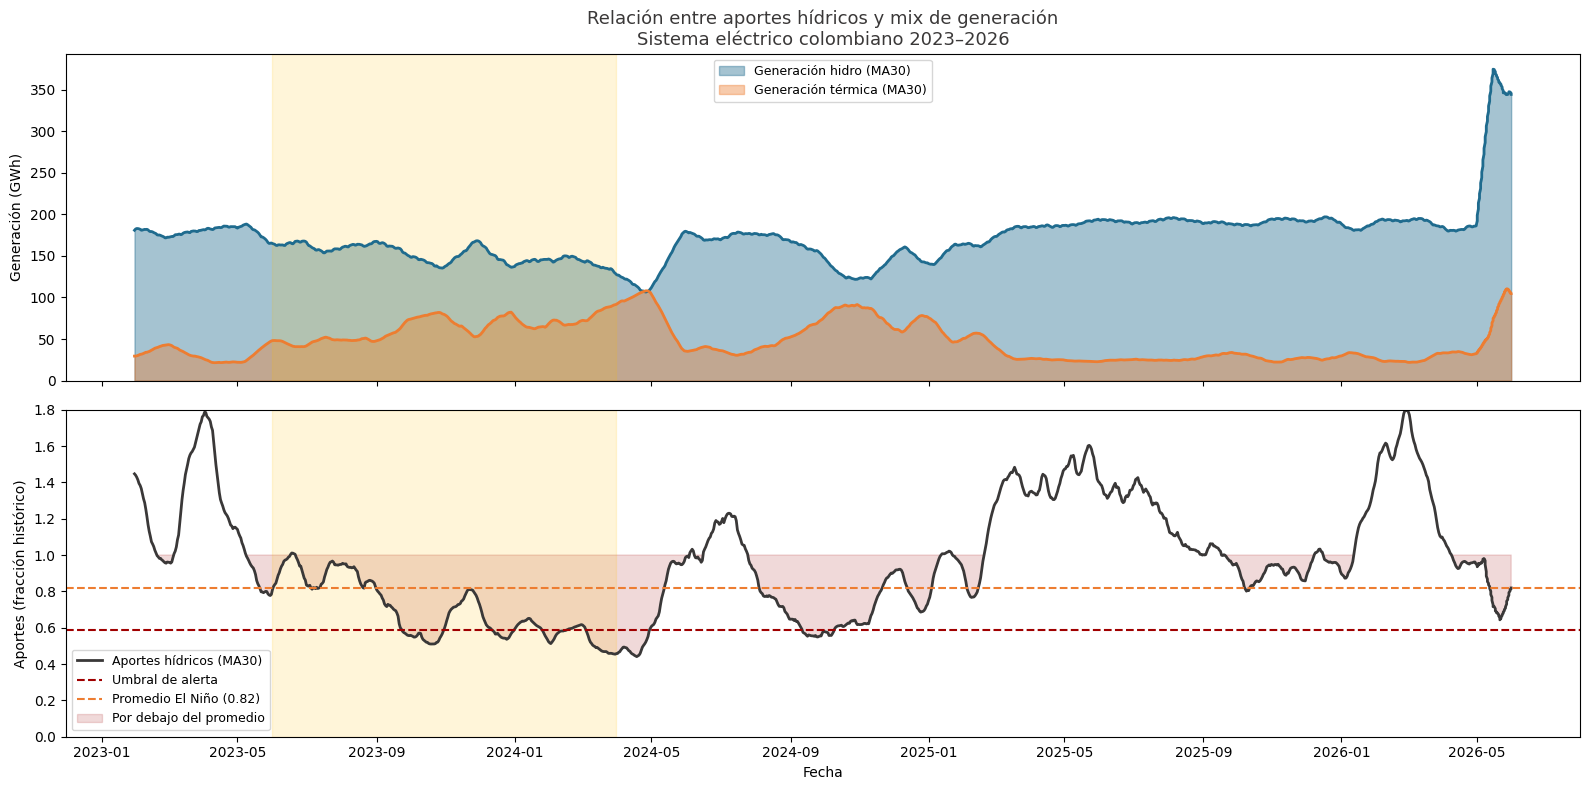

Gráfica guardada.


In [36]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# ── Panel superior: Hidro vs Térmica ──
ax1.fill_between(df_master['Date'], df_master['hidro_ma30'],
                 alpha=0.4, color='#1F6B8E', label='Generación hidro (MA30)')
ax1.fill_between(df_master['Date'], df_master['termo_ma30'],
                 alpha=0.4, color='#ED7D31', label='Generación térmica (MA30)')
ax1.plot(df_master['Date'], df_master['hidro_ma30'],
         color='#1F6B8E', linewidth=2)
ax1.plot(df_master['Date'], df_master['termo_ma30'],
         color='#ED7D31', linewidth=2)

# Sombrear ENOS
for inicio, fin in nino:
    if pd.Timestamp(fin) >= pd.Timestamp('2023-01-01'):
        ax1.axvspan(pd.Timestamp(inicio), pd.Timestamp(fin),
                    alpha=0.15, color='#FFC000')

ax1.set_ylabel('Generación (GWh)')
ax1.set_title('Relación entre aportes hídricos y mix de generación\n'
              'Sistema eléctrico colombiano 2023–2026',
              fontsize=13, color='#3A3838')
ax1.legend(fontsize=9)
ax1.set_ylim(0, None)

# ── Panel inferior: Aportes ──
ax2.plot(df_master['Date'], df_master['apor_ma30'],
         color='#3A3838', linewidth=2, label='Aportes hídricos (MA30)')
ax2.axhline(0.59, color='#A00000', linewidth=1.5,
            linestyle='--', label='Umbral de alerta')
ax2.axhline(media_nino, color='#ED7D31', linewidth=1.5,
            linestyle='--', label=f'Promedio El Niño ({media_nino:.2f})')
ax2.fill_between(df_master['Date'], df_master['apor_ma30'], 1.0,
                 where=(df_master['apor_ma30'] < 1.0),
                 alpha=0.15, color='#A00000', label='Por debajo del promedio')

# Sombrear ENOS
for inicio, fin in nino:
    if pd.Timestamp(fin) >= pd.Timestamp('2023-01-01'):
        ax2.axvspan(pd.Timestamp(inicio), pd.Timestamp(fin),
                    alpha=0.15, color='#FFC000')

ax2.set_ylabel('Aportes (fracción histórico)')
ax2.set_xlabel('Fecha')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1.8)

plt.tight_layout()
plt.savefig('../outputs/hidro_vs_termo_enos.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")